In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import numpy as np
import pandas as pd


# **BACA DATASET**

In [ ]:
df = pd.read_excel('/content/DATASET TIKTOK (RAW).csv.xlsx')
display(df)

,uid,cid,text,diggCount,createTime,replyCommentTotal
0,7370000000000000000,7560000000000000000,info sniper bayaran..,730,1759938496,50.0
1,7100000000000000000,7560000000000000000,silahkan di baca,2084,1760071251,1.0
2,7260000000000000000,7560000000000000000,ini cuma pengalihan doang biar rakyat gak ada ...,1086,1759934327,9.0
3,6810000000000000000,7560000000000000000,PEMERINTAH: bbm di haruskan campur etanol untu...,528,1759964328,8.0
4,7370000000000000000,7560000000000000000,apakah bayar pajak bisa di oplos 10% dengan da...,2027,1759934818,82.0
...,...,...,...,...,...,...
7995,6810000000000000000,7570000000000000000,pantesan aja motor aku rada brebet tapi untung...,0,1762050275,0.0
7996,7140000000000000000,7560000000000000000,kenapa aku terlahir menjadi WNI,0,1759931869,0.0
7997,7070000000000000000,7560000000000000000,"aku yg make supra, akhir² ini ngerasa agak bor...",0,1760328718,0.0
7998,7470000000000000000,7560000000000000000,Petronas pengen masuk indo lagi gak yah?,494,1760347441,NaN


# **Explanatory Data**

In [ ]:
print("Dataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nMissing Values:")
display(df.isnull().sum())

print("\nData Types:")
display(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   uid                8000 non-null   int64  
 1   cid                8000 non-null   int64  
 2   text               7897 non-null   object 
 3   diggCount          8000 non-null   int64  
 4   createTime         8000 non-null   int64  
 5   replyCommentTotal  7998 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 375.1+ KB

Descriptive Statistics:


,uid,cid,text,diggCount,createTime,replyCommentTotal
count,8.000000e+03,8.000000e+03,7897,8000.000000,8.000000e+03,7998.000000
unique,NaN,NaN,7326,NaN,NaN,NaN
top,NaN,NaN,😁,NaN,NaN,NaN
freq,NaN,NaN,71,NaN,NaN,NaN
mean,7.070571e+18,7.564894e+18,NaN,25.164875,1.761097e+09,0.412228
std,5.604771e+17,5.492493e+15,NaN,567.334053,1.079290e+06,3.413262
min,1.482502e+07,7.560000e+18,NaN,0.000000,1.759912e+09,0.000000
25%,6.910000e+18,7.560000e+18,NaN,0.000000,1.760053e+09,0.000000
50%,7.090000e+18,7.560000e+18,NaN,0.000000,1.760888e+09,0.000000
75%,7.330000e+18,7.570000e+18,NaN,1.000000,1.761846e+09,0.000000



Missing Values:


,0
uid,0
cid,0
text,103
diggCount,0
createTime,0
replyCommentTotal,2



Data Types:


,0
uid,int64
cid,int64
text,object
diggCount,int64
createTime,int64
replyCommentTotal,float64


## **PREPROCESSING**

In [ ]:
df_processed = df[['uid', 'cid', 'text']].copy()

# Pastikan kolom 'text' bertipe string, dan ubah jika ada NaN menjadi string kosong atau drop
df_processed['text'] = df_processed['text'].astype(str)

display(df_processed.head())

,uid,cid,text
0,7370000000000000000,7560000000000000000,info sniper bayaran..
1,7100000000000000000,7560000000000000000,silahkan di baca
2,7260000000000000000,7560000000000000000,ini cuma pengalihan doang biar rakyat gak ada ...
3,6810000000000000000,7560000000000000000,PEMERINTAH: bbm di haruskan campur etanol untu...
4,7370000000000000000,7560000000000000000,apakah bayar pajak bisa di oplos 10% dengan da...


### Menghapus Data Duplikat
Menghapus baris yang memiliki nilai duplikat.

In [ ]:
initial_rows = len(df_processed)
df_processed = df_processed.drop_duplicates(subset=['uid', 'cid', 'text']) # Specify columns to avoid hashing list columns
rows_after_duplicates = len(df_processed)
print(f"Jumlah baris sebelum menghapus duplikasi: {initial_rows}")
print(f"Jumlah baris setelah menghapus duplikasi: {rows_after_duplicates}")

# Menghapus baris dengan teks kosong setelah penghapusan duplikasi
# Ini mengidentifikasi string kosong dan mengubahnya menjadi NaN, lalu menghapus baris yang mengandung NaN tersebut.
# Catatan: Langkah ini juga dilakukan di sel berikutnya (26f9b2d8) untuk kolom 'text'.
rows_with_empty_text = df_processed['text'].replace('', np.nan).isnull().sum()
df_processed['text'] = df_processed['text'].replace('', np.nan) # Fixed FutureWarning
df_processed.dropna(subset=['text'], inplace=True)

print(f"Jumlah baris dengan teks kosong yang dihapus: {rows_with_empty_text}")
print(f"Jumlah baris setelah menghapus teks kosong: {len(df_processed)}")

display(df_processed.head())

Jumlah baris sebelum menghapus duplikasi: 8000
Jumlah baris setelah menghapus duplikasi: 7904
Jumlah baris dengan teks kosong yang dihapus: 0
Jumlah baris setelah menghapus teks kosong: 7904


,uid,cid,text
0,7370000000000000000,7560000000000000000,info sniper bayaran..
1,7100000000000000000,7560000000000000000,silahkan di baca
2,7260000000000000000,7560000000000000000,ini cuma pengalihan doang biar rakyat gak ada ...
3,6810000000000000000,7560000000000000000,PEMERINTAH: bbm di haruskan campur etanol untu...
4,7370000000000000000,7560000000000000000,apakah bayar pajak bisa di oplos 10% dengan da...


### Menghapus Kolom Kosong (atau Baris dengan Teks Kosong)
Karena kita sudah menyisakan hanya kolom 'id' dan 'text', langkah ini akan fokus pada menghapus baris di mana kolom 'text' mungkin kosong setelah diubah ke string atau jika ada nilai null.

In [ ]:
df_processed['text'] = df_processed['text'].replace('', np.nan) # Mengganti string kosong dengan NaN, Fixed FutureWarning
initial_text_nan_rows = df_processed['text'].isnull().sum()
df_processed.dropna(subset=['text'], inplace=True)
print(f"Jumlah baris dengan teks kosong/NaN yang dihapus: {initial_text_nan_rows}")
print(f"Jumlah baris setelah menghapus teks kosong/NaN: {len(df_processed)}")
display(df_processed.head())

Jumlah baris dengan teks kosong/NaN yang dihapus: 0
Jumlah baris setelah menghapus teks kosong/NaN: 7904


,uid,cid,text
0,7370000000000000000,7560000000000000000,info sniper bayaran..
1,7100000000000000000,7560000000000000000,silahkan di baca
2,7260000000000000000,7560000000000000000,ini cuma pengalihan doang biar rakyat gak ada ...
3,6810000000000000000,7560000000000000000,PEMERINTAH: bbm di haruskan campur etanol untu...
4,7370000000000000000,7560000000000000000,apakah bayar pajak bisa di oplos 10% dengan da...


### Cleansing
Menghapus karakter yang tidak diinginkan seperti URL, tagar, mention, angka, dan tanda baca dari kolom 'text_cleaned'.

### **2.1.4 Cleansing Teks**

Tahap *cleansing* bertujuan untuk menghilangkan elemen-elemen non-alfanumerik atau *noise* yang tidak relevan untuk analisis sentimen. Implementasi fungsi `clean_text` mencakup beberapa langkah:

*   **Menghapus *Mentions* (@user)**: Pola `@[A-Za-z0-9_]+` digunakan untuk mengidentifikasi dan menghapus sebutan pengguna (misalnya, `@username`).
*   **Menghapus *Hashtags* (#tag)**: Pola `#\w+` digunakan untuk menghilangkan tagar yang seringkali berfungsi sebagai kategori atau topik, namun tidak selalu berkontribusi langsung pada sentimen kalimat.
*   **Menghapus URL**: Pola `http\S+|www\S+` mengidentifikasi dan menghapus tautan web yang tidak memiliki nilai sentimen.
*   **Menghapus Angka dan Tanda Baca**: Pola `[^a-zA-Z\s]` membersihkan semua karakter selain huruf alfabet dan spasi. Ini penting untuk fokus pada inti semantik kata.
*   **Menghapus Spasi Berlebih**: `\s+` diganti dengan spasi tunggal dan `strip()` digunakan untuk menghilangkan spasi di awal dan akhir teks, memastikan format yang rapi.

Hasil dari proses *cleansing* ini disimpan dalam kolom baru, `text_cleaned`.


### Case Folding
Mengubah semua teks dalam kolom 'text' menjadi huruf kecil.

In [ ]:
import re

def clean_text(text):
    text = str(text) # Memastikan input adalah string
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Hapus mentions (@user)
    text = re.sub(r'#\w+', '', text)            # Hapus hashtags (#tag)
    text = re.sub(r'http\S+|www\S+', '', text)   # Hapus URLs

    # Menghapus angka secara eksplisit
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca (sisakan huruf dan spasi)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # CAse Folding
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df_processed['text_cleaned'] = df_processed['text'].apply(clean_text)
display(df_processed[['text', 'text_cleaned']].head())

,text,text_cleaned
0,info sniper bayaran..,info sniper bayaran
1,silahkan di baca,silahkan di baca
2,ini cuma pengalihan doang biar rakyat gak ada ...,ini cuma pengalihan doang biar rakyat gak ada ...
3,PEMERINTAH: bbm di haruskan campur etanol untu...,pemerintah bbm di haruskan campur etanol untuk...
4,apakah bayar pajak bisa di oplos 10% dengan da...,apakah bayar pajak bisa di oplos dengan daun p...


### Normalisasi Kata (opsional)
Melakukan normalisasi kata menggunakan kamus yang telah disediakan (`fikkamusnormalisasikata-2024.csv`).

In [ ]:
# Memuat kamus normalisasi
normalisasi_df = pd.read_csv('fikkamusnormalisasikata-2024.csv')
normalization_dict = dict(zip(normalisasi_df['tidak_baku'], normalisasi_df['kata_baku']))

# Tambahkan normalisasi slang yang diminta
normalization_dict['mbrebet'] = 'brebet'
normalization_dict['rebet'] = 'brebet'
normalization_dict['bahlull'] = 'bahlul'
normalization_dict['bensol'] = 'bensin'
normalization_dict['pertalit'] = 'pertalite'

# Tambahan normalisasi berdasarkan observasi dari sampel netral dan frekuensi token
normalization_dict['borosbnrt'] = 'boros'

def normalize_text(text, normalization_dict):
    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# Fungsi untuk menghitung kata yang berubah setelah normalisasi
def count_changed_words(original_text, normalization_dict):
    words = original_text.split()
    changed_count = 0
    for word in words:
        if word in normalization_dict and normalization_dict[word] != word:
            changed_count += 1
    return changed_count

# Hitung total kata yang berhasil dinormalisasi (berubah)
total_words_changed = df_processed['text_cleaned'].apply(lambda x: count_changed_words(x, normalization_dict)).sum()
print(f"Total kata yang berhasil dinormalisasi (berubah) menggunakan kamus: {total_words_changed}\n")

df_processed['text_cleaned'] = df_processed['text_cleaned'].apply(lambda x: normalize_text(x, normalization_dict))
display(df_processed[['text', 'text_cleaned']].head())

Total kata yang berhasil dinormalisasi (berubah) menggunakan kamus: 14928



,text,text_cleaned
0,info sniper bayaran..,info sniper bayaran
1,silahkan di baca,silakan di baca
2,ini cuma pengalihan doang biar rakyat gak ada ...,ini cuma pengalihan saja biar rakyat tidak ada...
3,PEMERINTAH: bbm di haruskan campur etanol untu...,pemerintah bbm di haruskan campur etanol untuk...
4,apakah bayar pajak bisa di oplos 10% dengan da...,apakah bayar pajak bisa di oplos dengan daun p...


### Tokenizing
Membagi teks yang sudah bersih menjadi kata-kata (token).

In [ ]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

df_processed['tokenized_text'] = df_processed['text_cleaned'].apply(word_tokenize)
display(df_processed[['text_cleaned', 'tokenized_text']].head())

,text_cleaned,tokenized_text
0,info sniper bayaran,"[info, sniper, bayaran]"
1,silakan di baca,"[silakan, di, baca]"
2,ini cuma pengalihan saja biar rakyat tidak ada...,"[ini, cuma, pengalihan, saja, biar, rakyat, ti..."
3,pemerintah bbm di haruskan campur etanol untuk...,"[pemerintah, bbm, di, haruskan, campur, etanol..."
4,apakah bayar pajak bisa di oplos dengan daun p...,"[apakah, bayar, pajak, bisa, di, oplos, dengan..."


### Stopword Removal
Menghapus kata-kata umum (stopwords) Bahasa Indonesia yang tidak memiliki makna signifikan dari token yang sudah ada.

In [ ]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Memuat stop words Bahasa Indonesia
stop_words_indonesian = set(stopwords.words('indonesian'))

df_processed['filtered_text'] = df_processed['tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words_indonesian])
display(df_processed[['tokenized_text', 'filtered_text']].head())

,tokenized_text,filtered_text
0,"[info, sniper, bayaran]","[info, sniper, bayaran]"
1,"[silakan, di, baca]","[silakan, baca]"
2,"[ini, cuma, pengalihan, saja, biar, rakyat, ti...","[pengalihan, biar, rakyat, UU, perampasan, aset]"
3,"[pemerintah, bbm, di, haruskan, campur, etanol...","[pemerintah, bbm, haruskan, campur, etanol, ke..."
4,"[apakah, bayar, pajak, bisa, di, oplos, dengan...","[bayar, pajak, oplos, daun, pisang]"


In [ ]:
additional_stopwords = {'sih', 'ya', 'nih', 'aja', 'mah', 'loh', 'bang', 'kak', 'om', 'an', 'e', 'nya'}

# Update stop_words_indonesian with additional_stopwords
stop_words_indonesian.update(additional_stopwords)

df_processed['filtered_text'] = df_processed['tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words_indonesian])
display(df_processed[['tokenized_text', 'filtered_text']].head())

,tokenized_text,filtered_text
0,"[info, sniper, bayaran]","[info, sniper, bayaran]"
1,"[silakan, di, baca]","[silakan, baca]"
2,"[ini, cuma, pengalihan, saja, biar, rakyat, ti...","[pengalihan, biar, rakyat, UU, perampasan, aset]"
3,"[pemerintah, bbm, di, haruskan, campur, etanol...","[pemerintah, bbm, haruskan, campur, etanol, ke..."
4,"[apakah, bayar, pajak, bisa, di, oplos, dengan...","[bayar, pajak, oplos, daun, pisang]"


### Normalisasi Kata (Setelah Stopword Removal)
Melakukan normalisasi kata menggunakan kamus yang telah disediakan (`fikkamusnormalisasikata-2024.csv`) pada teks setelah penghapusan *stopwords*.

In [ ]:
# The normalization_dict and normalize_text function are assumed to be defined in previous cells.
# If not, they would need to be re-defined here or imported.

# Apply normalization to the filtered_text
df_processed['normalized_filtered_text'] = df_processed['filtered_text'].apply(lambda x: [normalization_dict.get(word, word) for word in x])
display(df_processed[['filtered_text', 'normalized_filtered_text']].head())

,filtered_text,normalized_filtered_text
0,"[info, sniper, bayaran]","[info, sniper, bayaran ]"
1,"[silakan, baca]","[silahkan, baca]"
2,"[pengalihan, biar, rakyat, UU, perampasan, aset]","[pengalihan, biar, rakyat, UU, perampasan, ase..."
3,"[pemerintah, bbm, haruskan, campur, etanol, ke...","[pemerintah, bbm, haruskan, campur, etanol, ke..."
4,"[bayar, pajak, oplos, daun, pisang]","[bayar, pajak, oplos, daun, pisang]"


### Stemming
Mengubah kata-kata menjadi bentuk dasarnya menggunakan Sastrawi.

In [ ]:
!pip install Sastrawi -qq
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df_processed['stemmed_text'] = df_processed['normalized_filtered_text'].apply(lambda x: [stemmer.stem(word) for word in x])
display(df_processed[['normalized_filtered_text', 'stemmed_text']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.5 MB/s eta 0:00:00


,normalized_filtered_text,stemmed_text
0,"[info, sniper, bayaran ]","[info, sniper, bayar]"
1,"[silahkan, baca]","[silah, baca]"
2,"[pengalihan, biar, rakyat, UU, perampasan, ase...","[alih, biar, rakyat, uu, ampas, aset]"
3,"[pemerintah, bbm, haruskan, campur, etanol, ke...","[perintah, bbm, harus, campur, etanol, kendara..."
4,"[bayar, pajak, oplos, daun, pisang]","[bayar, pajak, oplos, daun, pisang]"


### Menggabungkan Kembali Teks yang Sudah Distemming


In [ ]:
df_processed['final_text'] = df_processed['stemmed_text'].apply(lambda x: ' '.join(x))
display(df_processed[['text', 'final_text']].head())

,text,final_text
0,info sniper bayaran..,info sniper bayar
1,silahkan di baca,silah baca
2,ini cuma pengalihan doang biar rakyat gak ada ...,alih biar rakyat uu ampas aset
3,PEMERINTAH: bbm di haruskan campur etanol untu...,perintah bbm harus campur etanol kendara rakya...
4,apakah bayar pajak bisa di oplos 10% dengan da...,bayar pajak oplos daun pisang


### Penentuan Kata Topik dan Stopword Tambahan

Berdasarkan arahan untuk memisahkan kata topik dari kata sentimen dan memperbarui stopword, berikut adalah daftar kata topik dan stopword tambahan yang akan digunakan dalam analisis sentimen.

In [ ]:
# Define topic words that should not be scored as sentiment unless part of a phrase
topic_words_list = [
    'motor', 'etanol', 'mesin', 'kendara', 'rakyat', 'pertamax', 'pertalite',
    'perintah', 'indonesia', 'bbm', 'tangki', 'bahan', 'bakar', 'harga', 'pajak', 'subsidi', 'negara', 'pemerintah', 'masyarakat', 'orang'
]
topic_words_set = set(topic_words_list)

# Remove sentiment-bearing words from topic_words_set as requested
sentiment_words_to_remove = {'rusak', 'brebet', 'mogok', 'karat', 'oplos', 'boros', 'hancur', 'ribet', 'ampas', 'bahaya', 'korosi', 'bahlul', 'goblok', 'jelek', 'rebet', 'mbrebet',"rampas"}
topic_words_set = topic_words_set - sentiment_words_to_remove

# Define additional stopwords as requested
additional_stopwords = {'sih', 'ya', 'nih', 'aja', 'mah', 'loh', 'bang', 'kak', 'om', 'an', 'e', 'nya'}

print("Topic Words (filtered): ", sorted(list(topic_words_set)))
print("Additional Stopwords: ", sorted(list(additional_stopwords)))

Topic Words (filtered):  ['bahan', 'bakar', 'bbm', 'etanol', 'harga', 'indonesia', 'kendara', 'masyarakat', 'mesin', 'motor', 'negara', 'orang', 'pajak', 'pemerintah', 'perintah', 'pertalite', 'pertamax', 'rakyat', 'subsidi', 'tangki']
Additional Stopwords:  ['aja', 'an', 'bang', 'e', 'kak', 'loh', 'mah', 'nih', 'nya', 'om', 'sih', 'ya']


### Menggabungkan Atribut Awal dengan Hasil Preprocessing

In [ ]:
combined_df = df_processed[['text', 'text_cleaned', 'tokenized_text', 'filtered_text' , 'stemmed_text', 'final_text']].copy()
display(combined_df.head())

,text,text_cleaned,tokenized_text,filtered_text,stemmed_text,final_text
0,info sniper bayaran..,info sniper bayaran,"[info, sniper, bayaran]","[info, sniper, bayaran]","[info, sniper, bayar]",info sniper bayar
1,silahkan di baca,silakan di baca,"[silakan, di, baca]","[silakan, baca]","[silah, baca]",silah baca
2,ini cuma pengalihan doang biar rakyat gak ada ...,ini cuma pengalihan saja biar rakyat tidak ada...,"[ini, cuma, pengalihan, saja, biar, rakyat, ti...","[pengalihan, biar, rakyat, UU, perampasan, aset]","[alih, biar, rakyat, uu, ampas, aset]",alih biar rakyat uu ampas aset
3,PEMERINTAH: bbm di haruskan campur etanol untu...,pemerintah bbm di haruskan campur etanol untuk...,"[pemerintah, bbm, di, haruskan, campur, etanol...","[pemerintah, bbm, haruskan, campur, etanol, ke...","[perintah, bbm, harus, campur, etanol, kendara...",perintah bbm harus campur etanol kendara rakya...
4,apakah bayar pajak bisa di oplos 10% dengan da...,apakah bayar pajak bisa di oplos dengan daun p...,"[apakah, bayar, pajak, bisa, di, oplos, dengan...","[bayar, pajak, oplos, daun, pisang]","[bayar, pajak, oplos, daun, pisang]",bayar pajak oplos daun pisang


### Word Cloud setelah Preprocessing

In [ ]:
!pip install wordcloud -qq

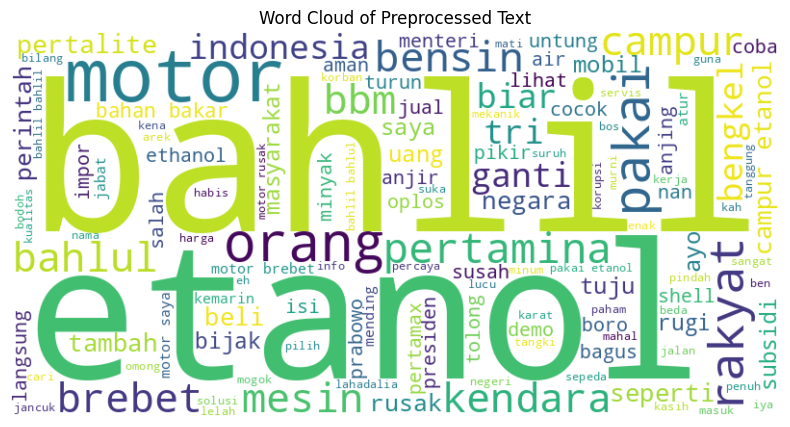

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua teks akhir menjadi satu string besar
all_final_text = ' '.join(df_processed['final_text'])

# Buat objek WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(all_final_text)

# Tampilkan Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Preprocessed Text')
plt.show()

### Pelabelan Sentimen Menggunakan Lexicon-Based

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from collections import Counter
import pandas as pd

factory = StemmerFactory()
stemmer = factory.create_stemmer()


def process_lexicon_dataframe(df, stemmer):
    unigram_lexicon = {}
    phrase_lexicon = {}

    for index, row in df.iterrows():
        original_word_or_phrase = str(row.iloc[0]).strip()
        try:
            score = float(row.iloc[1])
        except (ValueError, IndexError):
            score = 0.0


        if original_word_or_phrase.lower() in ['word', '']:
            continue

        stemmed_components = [stemmer.stem(word) for word in original_word_or_phrase.split()]
        stemmed_key = ' '.join(stemmed_components)

        if ' ' in stemmed_key:
            phrase_lexicon[stemmed_key] = score
        else:
            unigram_lexicon[stemmed_key] = score
    return unigram_lexicon, phrase_lexicon

# Load positive lexicon from CSV file
positive_df = pd.read_csv('Lexicon positive.csv')
positive_unigram_lexicon, positive_phrase_lexicon = process_lexicon_dataframe(positive_df, stemmer)

# Load negative lexicon from XLSX file
negative_df = pd.read_excel('Lexicon negative.xlsx')
negative_unigram_lexicon, negative_phrase_lexicon = process_lexicon_dataframe(negative_df, stemmer)

print(f"Jumlah kata dalam lexicon positif (unigram): {len(positive_unigram_lexicon)}")
print(f"Jumlah frasa dalam lexicon positif: {len(positive_phrase_lexicon)}")
print(f"Jumlah kata dalam lexicon negatif (unigram): {len(negative_unigram_lexicon)}")
print(f"Jumlah frasa dalam lexicon negatif: {len(negative_phrase_lexicon)}")

# Define negation words and booster words
negation_words = {'tidak', 'tak', 'ga', 'gak', 'enggak', 'bukan', 'kurang'}
booster_words = {'sangat', 'banget', 'parah', 'makin', 'terlalu'}

# Define the sentiment scoring function, now using separate unigram/phrase lexicons and topic words
def get_sentiment_score_enhanced(stemmed_tokens_list, pos_uni_lex, neg_uni_lex, pos_phrase_lex, neg_phrase_lex, topic_words_set, negation_words_set, booster_words_set):
    score = 0.0 # Use float for score to handle booster multiplication
    recognized_tokens = []
    consumed_indices = set()
    tokens_len = len(stemmed_tokens_list)

    # Step 1: Phrase Matching (iterate from longest phrases first)
    max_phrase_length = 0
    for phrase_key in pos_phrase_lex:
        max_phrase_length = max(max_phrase_length, len(phrase_key.split()))
    for phrase_key in neg_phrase_lex:
        max_phrase_length = max(max_phrase_length, len(phrase_key.split()))

    for length in range(max_phrase_length, 1, -1): # From max_phrase_length down to 2
        for i in range(tokens_len - length + 1):
            if any(j in consumed_indices for j in range(i, i + length)): # Skip if any part is already consumed
                continue

            current_phrase_tokens = stemmed_tokens_list[i : i + length]
            current_phrase_str = ' '.join(current_phrase_tokens)

            current_score = 0.0
            is_found = False

            if current_phrase_str in pos_phrase_lex:
                current_score = pos_phrase_lex[current_phrase_str]
                is_found = True
            elif current_phrase_str in neg_phrase_lex:
                current_score = neg_phrase_lex[current_phrase_str]
                is_found = True

            if is_found:
                # Apply negation (if preceded by a negation word)
                if i > 0 and stemmed_tokens_list[i-1] in negation_words_set:
                    current_score *= -1

                # Apply booster (if preceded by a booster word)
                if i > 0 and stemmed_tokens_list[i-1] in booster_words_set:
                    current_score *= 1.5

                score += current_score
                recognized_tokens.append(current_phrase_str)
                for j in range(i, i + length):
                    consumed_indices.add(j)

    # Step 2: Unigram Matching for remaining tokens
    for i, token in enumerate(stemmed_tokens_list):
        if i in consumed_indices: # Skip if already part of a phrase
            continue

        if token in topic_words_set: # Do not score topic words as unigrams
            continue

        is_booster_or_negation_only = (token in booster_words_set or token in negation_words_set) and \
                                      not (token in pos_uni_lex or token in neg_uni_lex)
        if is_booster_or_negation_only:
            continue

        current_score = 0.0
        is_found = False

        if token in pos_uni_lex:
            current_score = pos_uni_lex[token]
            is_found = True
        elif token in neg_uni_lex:
            current_score = neg_uni_lex[token]
            is_found = True

        if is_found:
            # Apply negation (if preceded by a negation word)
            if i > 0 and stemmed_tokens_list[i-1] in negation_words_set:
                current_score *= -1

            # Apply booster (if preceded by a booster word)
            if i > 0 and stemmed_tokens_list[i-1] in booster_words_set:
                current_score *= 1.5

            score += current_score
            recognized_tokens.append(token)

    return score, recognized_tokens

sentiment_bias_offset = 0.5 # Adjust this value (e.g., 0.0 for no bias, 0.1, 0.5, 1.0, etc.)
neutral_range_threshold = 0.5 # Define a range for 'Neutral' sentiment

def assign_sentiment_label_with_bias(score):
    effective_score = score - sentiment_bias_offset

    if effective_score > neutral_range_threshold:
        return 'Positive'
    elif effective_score < -neutral_range_threshold:
        return 'Negative'
    else:
        return 'Neutral'

results_list_enhanced = [
    get_sentiment_score_enhanced(
        x, positive_unigram_lexicon, negative_unigram_lexicon,
        positive_phrase_lexicon, negative_phrase_lexicon, topic_words_set, negation_words, booster_words
    ) for x in df_processed['stemmed_text']
]

df_processed['sentiment_score'] = [r[0] for r in results_list_enhanced]
df_processed['recognized_tokens'] = [r[1] for r in results_list_enhanced]
df_processed['sentiment_label'] = df_processed['sentiment_score'].apply(assign_sentiment_label_with_bias)

display(df_processed[['uid', 'final_text', 'sentiment_score', 'sentiment_label', 'recognized_tokens']].head())

print("\nJumlah Sentimen:")
sentiment_counts_new = df_processed['sentiment_label'].value_counts()
print(sentiment_counts_new)

# Calculate coverage with enhanced recognition
all_tokens = [token for sublist in df_processed['stemmed_text'] for token in sublist]
recognized_tokens_flat_new = [token for sublist in df_processed['recognized_tokens'] for token in sublist]

total_tokens = len(all_tokens)
num_recognized_tokens_new = len(set(recognized_tokens_flat_new))
coverage_new = (num_recognized_tokens_new / total_tokens) * 100 if total_tokens > 0 else 0

print("\n===== LEXICON COVERAGE (After Enhancement) ====")
print(f"Total Token           : {total_tokens}")
print(f"Recognized Unique Token : {num_recognized_tokens_new}")
print(f"Coverage Lexicon (%)  : {coverage_new:.2f}%")

Jumlah kata dalam lexicon positif (unigram): 148
Jumlah frasa dalam lexicon positif: 157
Jumlah kata dalam lexicon negatif (unigram): 294
Jumlah frasa dalam lexicon negatif: 177


,uid,final_text,sentiment_score,sentiment_label,recognized_tokens
0,7370000000000000000,info sniper bayar,-3.0,Negative,[sniper]
1,7100000000000000000,silah baca,0.0,Neutral,[]
2,7260000000000000000,alih biar rakyat uu ampas aset,-11.0,Negative,"[biar, ampas, aset]"
3,6810000000000000000,perintah bbm harus campur etanol kendara rakya...,-4.0,Negative,"[campur, campur]"
4,7370000000000000000,bayar pajak oplos daun pisang,-4.0,Negative,[oplos]



Jumlah Sentimen:
sentiment_label
Negative    3656
Neutral     2989
Positive    1259
Name: count, dtype: int64

===== LEXICON COVERAGE (After Enhancement) ====
Total Token           : 36139
Recognized Unique Token : 314
Coverage Lexicon (%)  : 0.87%


In [ ]:
zero_sentiment_score_count = (df_processed['sentiment_score'] == 0).sum()
print(f"Jumlah data dengan sentiment_score = 0: {zero_sentiment_score_count}")

Jumlah data dengan sentiment_score = 0: 2726


In [ ]:
df_zero_sentiment = df_processed[df_processed['sentiment_score'] == 0]
display(df_zero_sentiment[['final_text', 'sentiment_score', 'sentiment_label']].head(100))

,final_text,sentiment_score,sentiment_label
1,silah baca,0.0,Neutral
6,nan,0.0,Neutral
33,efek katawa,0.0,Neutral
37,utak atik bbm hawatir rakyat beli,0.0,Neutral
38,punah,0.0,Neutral
...,...,...,...
362,,0.0,Neutral
363,tuan miles axlerod temu alinol,0.0,Neutral
365,kelet wiii mesin engko,0.0,Neutral
372,ay serah,0.0,Neutral


### Pembagian Dataset (80:20) dengan Label Sentimen Terbaru

In [ ]:
from sklearn.model_selection import train_test_split

# Redefine X and Y from the updated df_processed
X_new = df_processed['final_text']  # Fitur: teks yang sudah diproses
Y_new = df_processed['sentiment_label'] # Target: label sentimen

# Bagi data menjadi training (80%) dan testing (20%)
# Pastikan stratify berdasarkan Y_new untuk menjaga proporsi kelas, termasuk 'Neutral'
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, Y_new, test_size=0.2, random_state=42, stratify=Y_new)

print(f"Ukuran X_train_new: {X_train_new.shape}")
print(f"Ukuran X_test_new: {X_test_new.shape}")
print(f"Ukuran y_train_new: {y_train_new.shape}")
print(f"Ukuran y_test_new: {y_test_new.shape}")

print("\nDistribusi sentimen dalam y_train_new:")
print(y_train_new.value_counts(normalize=True))

print("\nDistribusi sentimen dalam y_test_new:")
print(y_test_new.value_counts(normalize=True))

Ukuran X_train_new: (6323,)
Ukuran X_test_new: (1581,)
Ukuran y_train_new: (6323,)
Ukuran y_test_new: (1581,)

Distribusi sentimen dalam y_train_new:
sentiment_label
Negative    0.462597
Neutral     0.378143
Positive    0.159260
Name: proportion, dtype: float64

Distribusi sentimen dalam y_test_new:
sentiment_label
Negative    0.462366
Neutral     0.378242
Positive    0.159393
Name: proportion, dtype: float64


### Vektorisasi Teks dengan TF-IDF (Diperbarui)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TfidfVectorizer
tfidf_vectorizer_new = TfidfVectorizer(max_features=5000)

# Pelajari kosakata dari data training dan transformasikan data training
X_train_tfidf_new = tfidf_vectorizer_new.fit_transform(X_train_new)

# Transformasikan data testing menggunakan vocabulary yang telah dipelajari dari data training
X_test_tfidf_new = tfidf_vectorizer_new.transform(X_test_new)

print(f"Ukuran X_train_tfidf_new: {X_train_tfidf_new.shape}")
print(f"Ukuran X_test_tfidf_new: {X_test_tfidf_new.shape}")

Ukuran X_train_tfidf_new: (6323, 5000)
Ukuran X_test_tfidf_new: (1581, 5000)


In [ ]:
feature_names = tfidf_vectorizer_new.get_feature_names_out()

# Matriks TF-IDF dalam bentuk DataFrame (diperlukan untuk perhitungan)
df_tfidf = pd.DataFrame(X_train_tfidf_new.toarray(), columns=feature_names)
df_tfidf.index = X_train_new.index # Menjaga indeks asli

# Tambahkan kolom sentiment_label ke df_tfidf
df_tfidf['sentiment_label'] = y_train_new

# Menghitung total bobot TF-IDF untuk setiap dokumen
df_tfidf['total_tfidf_weight'] = df_tfidf.drop(columns='sentiment_label').sum(axis=1)

print("#### **Dokumen dengan Bobot TF-IDF Tertinggi per Kategori Sentimen**")
print("Berikut adalah dokumen dengan total bobot TF-IDF tertinggi untuk setiap kategori sentimen (Positive, Negative, Neutral).")

top_documents_per_sentiment = pd.DataFrame()
for label in y_train_new.unique():
    # Filter dokumen untuk label sentimen saat ini
    df_label = df_tfidf[df_tfidf['sentiment_label'] == label]

    # Ambil dokumen dengan bobot TF-IDF tertinggi untuk label ini
    if not df_label.empty:
        top_doc = df_label.sort_values(by='total_tfidf_weight', ascending=False).head(1)
        top_documents_per_sentiment = pd.concat([top_documents_per_sentiment, top_doc])

display(top_documents_per_sentiment[['sentiment_label', 'total_tfidf_weight']].sort_values(by='sentiment_label'))

print("\nDetail dokumen terpilih:")

documents_details = []
for idx, row in top_documents_per_sentiment.iterrows():
    original_text_idx = row.name # Get the original index from df_processed
    sentiment = row['sentiment_label']
    tfidf_weight = row['total_tfidf_weight']
    original_comment = df_processed.loc[original_text_idx, 'text']
    final_text = df_processed.loc[original_text_idx, 'final_text']

    # Get top terms for this specific document
    doc_tfidf_vector_numerical = pd.to_numeric(row[feature_names], errors='coerce').fillna(0)
    top_terms = doc_tfidf_vector_numerical.nlargest(5)

    top_terms_str = "; ".join([f"'{term}': {tfidf_val:.4f}" for term, tfidf_val in top_terms.items()])

    documents_details.append({
        'Sentiment': sentiment,
        'Total TF-IDF Weight': f"{tfidf_weight:.4f}",
        'Original Comment': original_comment,
        'Processed Text': final_text,
        'Top Terms (TF-IDF)': top_terms_str
    })

df_documents_details = pd.DataFrame(documents_details)
display(df_documents_details)

#### **Dokumen dengan Bobot TF-IDF Tertinggi per Kategori Sentimen**
Berikut adalah dokumen dengan total bobot TF-IDF tertinggi untuk setiap kategori sentimen (Positive, Negative, Neutral).


,sentiment_label,total_tfidf_weight
4023,Negative,7.231860
182,Neutral,5.421342
1380,Positive,6.812539



Detail dokumen terpilih:


,Sentiment,Total TF-IDF Weight,Original Comment,Processed Text,Top Terms (TF-IDF)
0,Negative,7.2319,Mari kita bedah statement bapak @bahlillahadal...,mari bedah statement bahan kimia etanol aman k...,'bakar': 0.3107; 'mesin': 0.2651; 'sepeda': 0....
1,Neutral,5.4213,di Amerika. yang pakai etanol justru lebih mur...,amerika pakai etanol murah selisih harga mungk...,'ron': 0.3377; 'tambah': 0.2248; 'indonesia': ...
2,Positive,6.8125,Isu Pertalite dicampur ethanol sebenarnya tida...,isu pertalite campur ethanol sepenuh negatif e...,'ethanol': 0.3461; 'energi': 0.2973; 'bahan': ...


### Melatih Model SVM Baru pada Data yang Direduksi Dimensi (Diperbarui)

## Pelatihan Model Klasifikasi (SVM) Tanpa Oversampling (SMOTE) Menggunakan 3 Kelas

Model SVC dengan kernel linear berhasil dilatih.

Training Accuracy (80:20) : 0.9663

Classification Report :
               precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      2925
     Neutral       0.96      0.96      0.96      2391
    Positive       0.96      0.94      0.95      1007

    accuracy                           0.97      6323
   macro avg       0.96      0.96      0.96      6323
weighted avg       0.97      0.97      0.97      6323

Test Accuracy : 0.9039

Classification Report :
               precision    recall  f1-score   support

    Negative       0.94      0.93      0.93       731
     Neutral       0.88      0.91      0.89       598
    Positive       0.87      0.82      0.84       252

    accuracy                           0.90      1581
   macro avg       0.89      0.89      0.89      1581
weighted avg       0.90      0.90      0.90      1581


Confusion Matrix ( 80:20 split):


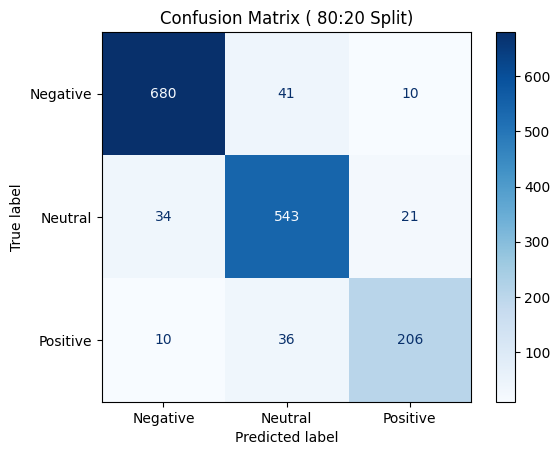

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Inisialisasi model SVC baru dengan kernel linear (tanpa SMOTE)
svm_model_no_smote_3class = SVC(kernel='linear', random_state=42)

# Latih model menggunakan data training TF-IDF asli (tanpa SMOTE) dengan 3 kelas
# Menggunakan X_train_tfidf_new dan y_train_new yang belum di-SMOTE
svm_model_no_smote_3class.fit(X_train_tfidf_new, y_train_new)

print("Model SVC dengan kernel linear berhasil dilatih.")

# Evaluasi performa pada data training asli
y_train_pred_no_smote_3class = svm_model_no_smote_3class.predict(X_train_tfidf_new)
print(f"\nTraining Accuracy (80:20) : {accuracy_score(y_train_new, y_train_pred_no_smote_3class):.4f}")
print("\nClassification Report :\n", classification_report(y_train_new, y_train_pred_no_smote_3class))
# Prediksi pada data testing menggunakan model tanpa SMOTE (3 kelas)
y_test_pred_no_smote_3class = svm_model_no_smote_3class.predict(X_test_tfidf_new)

print(f"Test Accuracy : {accuracy_score(y_test_new, y_test_pred_no_smote_3class):.4f}")
print("\nClassification Report :\n", classification_report(y_test_new, y_test_pred_no_smote_3class))

# Calculate and display Confusion Matrix for the 80:20 split (no SMOTE)
cm_no_smote_80_20 = confusion_matrix(y_test_new, y_test_pred_no_smote_3class, labels=svm_model_no_smote_3class.classes_)
disp_no_smote_80_20 = ConfusionMatrixDisplay(confusion_matrix=cm_no_smote_80_20, display_labels=svm_model_no_smote_3class.classes_)

print("\nConfusion Matrix ( 80:20 split):")
disp_no_smote_80_20.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix ( 80:20 Split)')
plt.show()

## Evaluasi Model Tanpa SMOTE pada Data Pengujian (3 Kelas)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Redefine X and Y using the 3-class sentiment labels
X_70_30 = df_processed['final_text']
Y_70_30 = df_processed['sentiment_label']

# Bagi data menjadi training (70%) dan testing (30%) tanpa SMOTE
X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30 = train_test_split(X_70_30, Y_70_30, test_size=0.3, random_state=42, stratify=Y_70_30)

print(f"Ukuran X_train (70:30): {X_train_70_30.shape}")
print(f"Ukuran X_test (70:30): {X_test_70_30.shape}")
print(f"Ukuran y_train (70:30): {y_train_70_30.shape}")
print(f"Ukuran y_test (70:30): {y_test_70_30.shape}")

print("\nDistribusi sentimen dalam y_train (70:30):")
print(y_train_70_30.value_counts(normalize=True))

print("\nDistribusi sentimen dalam y_test (70:30):")
print(y_test_70_30.value_counts(normalize=True))

Ukuran X_train (70:30): (5532,)
Ukuran X_test (70:30): (2372,)
Ukuran y_train (70:30): (5532,)
Ukuran y_test (70:30): (2372,)

Distribusi sentimen dalam y_train (70:30):
sentiment_label
Negative    0.462581
Neutral     0.378163
Positive    0.159255
Name: proportion, dtype: float64

Distribusi sentimen dalam y_test (70:30):
sentiment_label
Negative    0.462479
Neutral     0.378162
Positive    0.159359
Name: proportion, dtype: float64


### Vektorisasi Teks dengan TF-IDF (70:30 Split)

In [ ]:
# Inisialisasi TfidfVectorizer
tfidf_vectorizer_70_30 = TfidfVectorizer(max_features=5000)

# Pelajari kosakata dari data training dan transformasikan data training
X_train_tfidf_70_30 = tfidf_vectorizer_70_30.fit_transform(X_train_70_30)

# Transformasikan data testing menggunakan vocabulary yang telah dipelajari dari data training
X_test_tfidf_70_30 = tfidf_vectorizer_70_30.transform(X_test_70_30)

print(f"Ukuran X_train_tfidf (70:30): {X_train_tfidf_70_30.shape}")
print(f"Ukuran X_test_tfidf (70:30): {X_test_tfidf_70_30.shape}")

Ukuran X_train_tfidf (70:30): (5532, 5000)
Ukuran X_test_tfidf (70:30): (2372, 5000)


### Pelatihan dan Evaluasi Model SVM Tanpa Oversampling (70:30 Split, 3 Kelas)

Model SVC dengan kernel linear berhasil dilatih  (70:30 split, 3 kelas).

Training Accuracy: 0.9693

Classification Report (Training Data 70:30 split):
               precision    recall  f1-score   support

    Negative       0.98      0.98      0.98      2559
     Neutral       0.96      0.96      0.96      2092
    Positive       0.97      0.95      0.96       881

    accuracy                           0.97      5532
   macro avg       0.97      0.97      0.97      5532
weighted avg       0.97      0.97      0.97      5532


Test Accuracy ( 70:30 split): 0.8912

Classification Report (70:30 split):
               precision    recall  f1-score   support

    Negative       0.93      0.93      0.93      1097
     Neutral       0.86      0.89      0.87       897
    Positive       0.85      0.77      0.81       378

    accuracy                           0.89      2372
   macro avg       0.88      0.87      0.87      2372
weighted avg       0.89      0.89      0.89      2372


Confusi

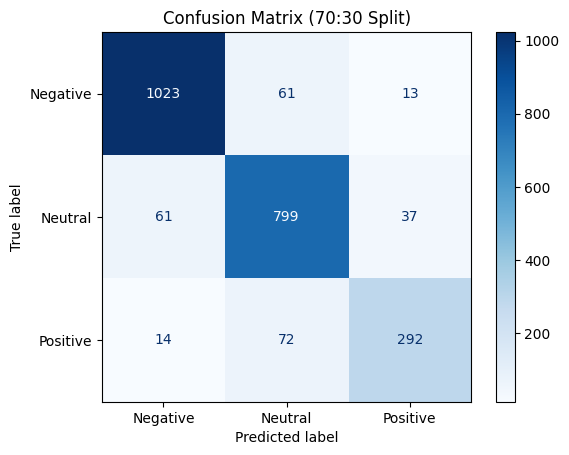

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Inisialisasi model SVC baru dengan kernel linear (tanpa SMOTE)
svm_model_no_smote_70_30 = SVC(kernel='linear', random_state=42)

# Latih model menggunakan data training TF-IDF asli (tanpa SMOTE)
svm_model_no_smote_70_30.fit(X_train_tfidf_70_30, y_train_70_30)

print("Model SVC dengan kernel linear berhasil dilatih  (70:30 split, 3 kelas).")

# Evaluasi performa pada data training asli
y_train_pred_no_smote_70_30 = svm_model_no_smote_70_30.predict(X_train_tfidf_70_30)
print(f"\nTraining Accuracy: {accuracy_score(y_train_70_30, y_train_pred_no_smote_70_30):.4f}")
print("\nClassification Report (Training Data 70:30 split):\n", classification_report(y_train_70_30, y_train_pred_no_smote_70_30))

# Prediksi pada data testing
y_test_pred_no_smote_70_30 = svm_model_no_smote_70_30.predict(X_test_tfidf_70_30)
print(f"\nTest Accuracy ( 70:30 split): {accuracy_score(y_test_70_30, y_test_pred_no_smote_70_30):.4f}")
print("\nClassification Report (70:30 split):\n", classification_report(y_test_70_30, y_test_pred_no_smote_70_30))

# Calculate and display Confusion Matrix for the 70:30 split (no SMOTE)
cm_no_smote_70_30 = confusion_matrix(y_test_70_30, y_test_pred_no_smote_70_30, labels=svm_model_no_smote_70_30.classes_)
disp_no_smote_70_30 = ConfusionMatrixDisplay(confusion_matrix=cm_no_smote_70_30, display_labels=svm_model_no_smote_70_30.classes_)

print("\nConfusion Matrix (70:30 split):")
disp_no_smote_70_30.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (70:30 Split)')
plt.show()

## **HASIL KLASIFIKASI**

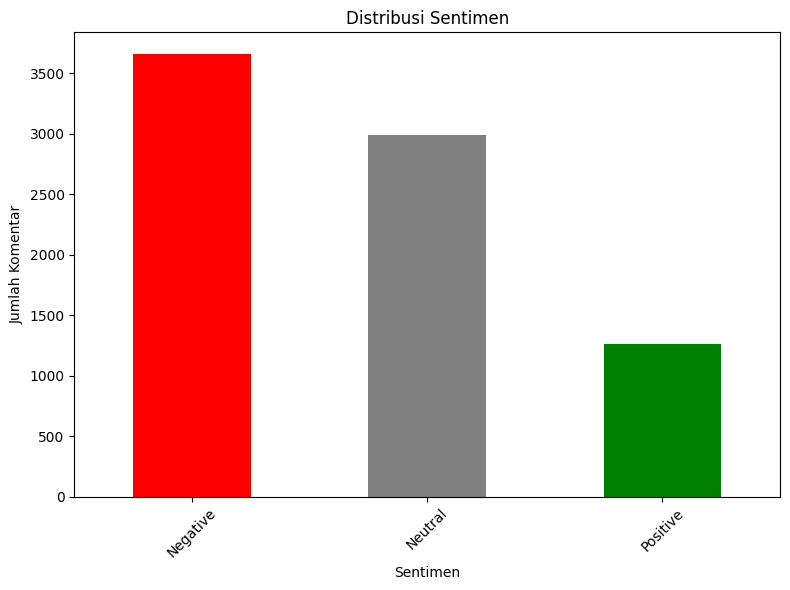

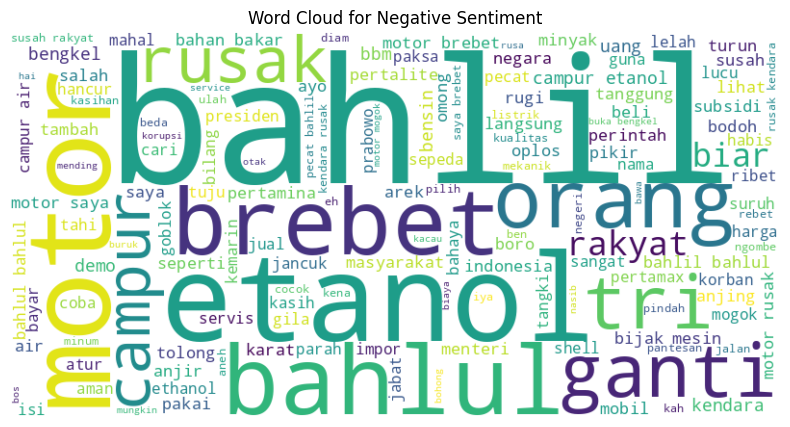

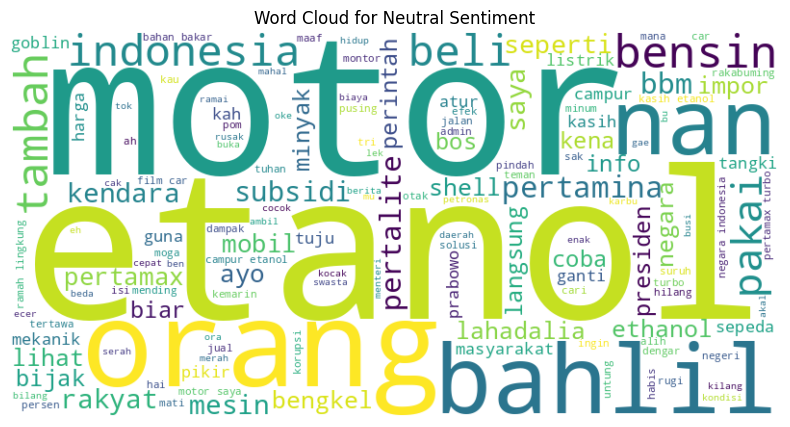

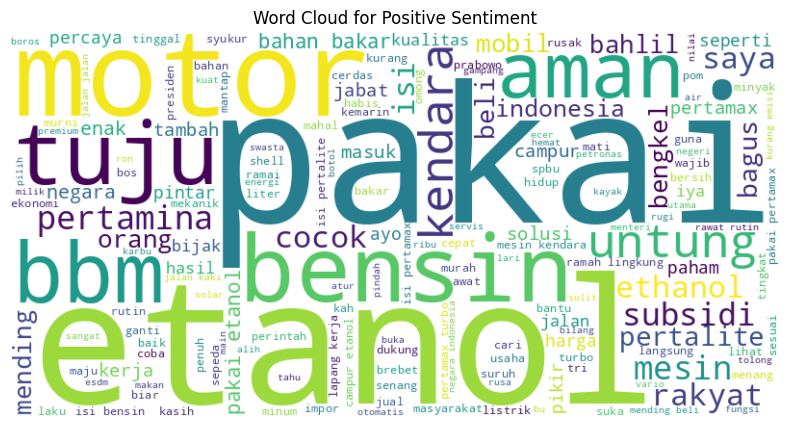

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Plotting Sentiment Distribution
plt.figure(figsize=(8, 6))
sentiment_counts = df_processed['sentiment_label'].value_counts()
sentiment_counts.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Generating Word Clouds for Each Sentiment
sentiments = df_processed['sentiment_label'].unique()

for sentiment in sentiments:
    # Filter text for the current sentiment
    sentiment_text = ' '.join(df_processed[df_processed['sentiment_label'] == sentiment]['final_text'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(sentiment_text)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()

# **VISUALISASI HYPERPLANE PLOT**

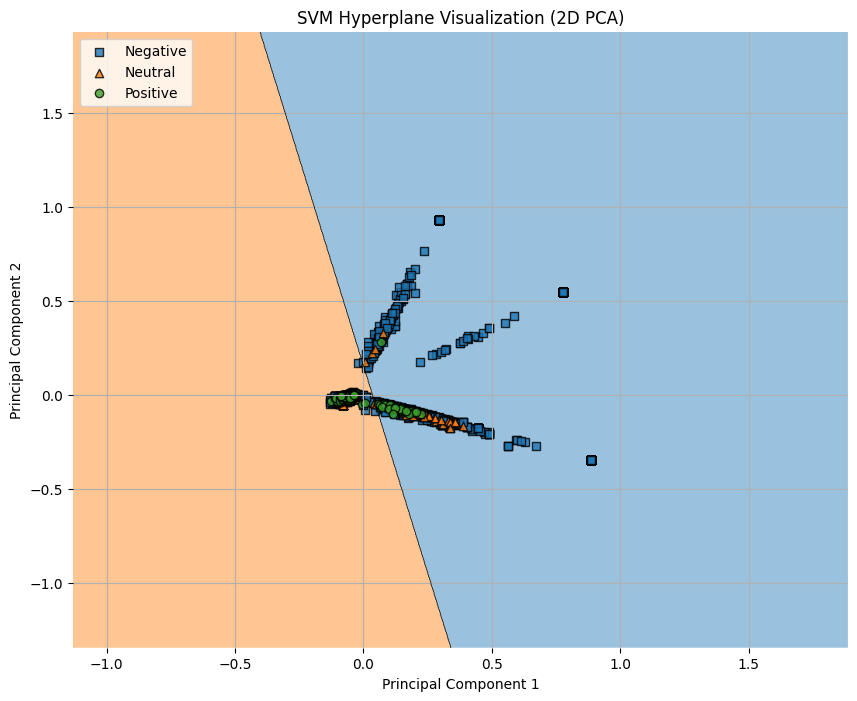

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # Changed back to PCA
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

# Asumsi X_train_tfidf_new dan y_train_new sudah ada dari sel sebelumnya
# X_train_tfidf_new adalah sparse matrix, ubah ke dense array untuk PCA
X_train_dense = X_train_tfidf_new.toarray()

# 1. Reduksi Dimensi dengan PCA ke 2 komponen
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_dense) # Changed variable name back to pca

# Encode target labels to numerical for plotting (plot_decision_regions requires numerical labels)
# Get unique labels and map them to integers
unique_labels = y_train_new.unique()
label_mapping = {label: i for i, label in enumerate(unique_labels)}
y_train_encoded = y_train_new.map(label_mapping).values

# 2. Latih model SVM baru pada data PCA yang direduksi
# Menggunakan kernel linear untuk hyperplane yang jelas
svm_model_pca = SVC(kernel='linear', random_state=42) # Changed model name back to pca
svm_model_pca.fit(X_train_pca, y_train_encoded) # Changed data input back to pca

# 3. Visualisasi Hyperplane
plt.figure(figsize=(10, 8))
# Assign the result directly to 'ax' as plot_decision_regions is returning an Axes object
ax = plot_decision_regions(X=X_train_pca, y=y_train_encoded, clf=svm_model_pca, legend=2) # Changed data and clf input back to pca

# Menambahkan judul dan label menggunakan metode Axes object
ax.set_xlabel('Principal Component 1') # Changed label back to PCA
ax.set_ylabel('Principal Component 2') # Changed label back to PCA
ax.set_title('SVM Hyperplane Visualization (2D PCA)') # Changed title back to PCA

# Mengganti label angka di legenda kembali ke nama sentimen asli
# Get the existing legend object from the axes
current_legend = ax.get_legend()

# Extract handles and numerical labels from the current legend
handles = current_legend.legend_handles
numerical_labels_str = [text.get_text() for text in current_legend.texts]

# Map these numerical labels back to their original sentiment names
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
new_labels = [reverse_label_mapping[int(label_str)] for label_str in numerical_labels_str]

# Remove the old legend created by plot_decision_regions
current_legend.remove()

# Add the new legend with custom labels to the 'ax' (Axes) object
ax.legend(handles, new_labels, loc='upper left')

plt.grid(True)
plt.show()